---
title: "Practice Activity 8.1"
format: 
    html:
        embed-resources: true
code-fold: true
echo: true
---

# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

**Dummify** all variables that require this.

In [3]:
# Code Here
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, root_mean_squared_error

In [4]:
pip install palmerpenguins

In [5]:
from palmerpenguins import load_penguins

penguins_df = load_penguins()
penguins_df.dropna(inplace=True)
penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [6]:
ct = ColumnTransformer(
  [
    ("dummify",
    OneHotEncoder(sparse_output = False, handle_unknown='ignore'),
    make_column_selector(dtype_include=object)),
    ("standardize",
    StandardScaler(),
    make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
)

Let's use the other variables to predict `bill_depth_mm`. Prepare your data and fit the following models on the entire dataset:

* Your best multiple linear regression model from before
* Two kNN models (for different values of K)
* A decision tree model

Create a plot like the right plot of Fig 1. in our `Model Validation` chapter with the training and test error plotted for each of your four models.

Which of your models was best?

In [7]:
# Linear Regression Model
X = penguins_df.drop(columns="bill_depth_mm")
y = penguins_df["bill_depth_mm"]

lr_pipeline = Pipeline(
  [("preprocessing", ct),
  ("linear_regression", LinearRegression())
  ]
)

In [8]:
cross_val_score(lr_pipeline, X, y, cv = 5, scoring = 'r2')

array([0.16747199, 0.20092912, 0.64013196, 0.39121607, 0.57444004])

In [9]:
lr_pipeline_fitted = lr_pipeline.fit(X, y)

lr_pipeline_fitted

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x79db6c27bc80>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x79db6c27bce0>)])),
                ('linear_regression', LinearRegression())])

In [10]:
# kNN Models
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline

X = penguins_df.drop(columns="bill_depth_mm")
y = penguins_df["bill_depth_mm"]

knn_pipeline1 = Pipeline(
  [("preprocessing", ct),
  ("knn_regressor", KNeighborsRegressor())
  ]
)
param_grid = {
  "knn_regressor__n_neighbors": [5]
}
gscv = GridSearchCV(knn_pipeline1, param_grid=param_grid, cv = 5, scoring='r2')

In [11]:
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

{'mean_fit_time': array([0.00976195]),
 'std_fit_time': array([0.00179058]),
 'mean_score_time': array([0.00636168]),
 'std_score_time': array([0.00073972]),
 'param_knn_regressor__n_neighbors': masked_array(data=[5],
              mask=[False],
        fill_value=999999),
 'params': [{'knn_regressor__n_neighbors': 5}],
 'split0_test_score': array([0.0876028]),
 'split1_test_score': array([0.13508584]),
 'split2_test_score': array([0.75085129]),
 'split3_test_score': array([0.61759977]),
 'split4_test_score': array([-0.85692026]),
 'mean_test_score': array([0.14684389]),
 'std_test_score': array([0.56526565]),
 'rank_test_score': array([1], dtype=int32)}

In [12]:
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)

df_cv_results_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn_regressor__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.009762,0.001791,0.006362,0.00074,5,{'knn_regressor__n_neighbors': 5},0.087603,0.135086,0.750851,0.6176,-0.85692,0.146844,0.565266,1


In [13]:
knn_pipeline2 = Pipeline(
  [("preprocessing", ct),
  ("knn_regressor", KNeighborsRegressor())
  ]
)
param_grid1 = {
  "knn_regressor__n_neighbors": [10]
}
gscv1 = GridSearchCV(knn_pipeline2, param_grid=param_grid1, cv = 5, scoring='r2')

In [14]:
gscv_fitted1 = gscv1.fit(X, y)

gscv_fitted1.cv_results_

{'mean_fit_time': array([0.00966258]),
 'std_fit_time': array([0.00197031]),
 'mean_score_time': array([0.0063797]),
 'std_score_time': array([0.00072904]),
 'param_knn_regressor__n_neighbors': masked_array(data=[10],
              mask=[False],
        fill_value=999999),
 'params': [{'knn_regressor__n_neighbors': 10}],
 'split0_test_score': array([0.20227363]),
 'split1_test_score': array([0.23691842]),
 'split2_test_score': array([0.74455312]),
 'split3_test_score': array([0.59757189]),
 'split4_test_score': array([-1.03703853]),
 'mean_test_score': array([0.14885571]),
 'std_test_score': array([0.62819667]),
 'rank_test_score': array([1], dtype=int32)}

In [15]:
df_cv_results_1 = pd.DataFrame(gscv_fitted1.cv_results_)

df_cv_results_1

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn_regressor__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.009663,0.00197,0.00638,0.000729,10,{'knn_regressor__n_neighbors': 10},0.202274,0.236918,0.744553,0.597572,-1.037039,0.148856,0.628197,1


In [16]:
# Decision Tree
dummies = pd.get_dummies(penguins_df, columns=['species', 'island', 'sex'], drop_first=True)

X = dummies.drop(columns='bill_depth_mm')
y = dummies['bill_depth_mm']

dt = DecisionTreeRegressor(max_depth=2)

dt

DecisionTreeRegressor(max_depth=2)

In [17]:
dt.fit(X, y)

DecisionTreeRegressor(max_depth=2)

In [18]:
dt.predict(X)

array([19.12990654, 17.61121495, 17.61121495, 17.61121495, 19.12990654,
       17.61121495, 19.12990654, 17.61121495, 19.12990654, 19.12990654,
       17.61121495, 17.61121495, 19.12990654, 17.61121495, 19.12990654,
       17.61121495, 19.12990654, 17.61121495, 19.12990654, 19.12990654,
       17.61121495, 19.12990654, 17.61121495, 17.61121495, 19.12990654,
       17.61121495, 19.12990654, 17.61121495, 19.12990654, 17.61121495,
       19.12990654, 19.12990654, 17.61121495, 17.61121495, 19.12990654,
       17.61121495, 19.12990654, 17.61121495, 19.12990654, 17.61121495,
       19.12990654, 19.12990654, 17.61121495, 19.12990654, 17.61121495,
       19.12990654, 17.61121495, 19.12990654, 17.61121495, 19.12990654,
       17.61121495, 19.12990654, 17.61121495, 19.12990654, 17.61121495,
       19.12990654, 17.61121495, 19.12990654, 17.61121495, 19.12990654,
       17.61121495, 19.12990654, 17.61121495, 19.12990654, 17.61121495,
       19.12990654, 17.61121495, 19.12990654, 17.61121495, 19.12

[Text(0.5, 0.8333333333333334, 'x[5] <= 0.5\nsquared_error = 3.866\nsamples = 333\nvalue = 17.165'),
 Text(0.25, 0.5, 'x[8] <= 0.5\nsquared_error = 1.412\nsamples = 214\nvalue = 18.371'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.787\nsamples = 107\nvalue = 17.611'),
 Text(0.375, 0.16666666666666666, 'squared_error = 0.884\nsamples = 107\nvalue = 19.13'),
 Text(0.75, 0.5, 'x[8] <= 0.5\nsquared_error = 0.964\nsamples = 119\nvalue = 14.997'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.287\nsamples = 58\nvalue = 14.238'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.54\nsamples = 61\nvalue = 15.718')]

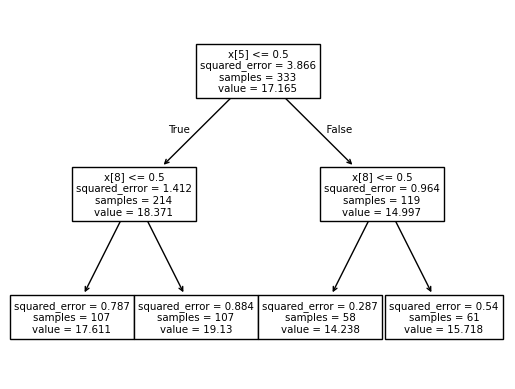

In [19]:
from sklearn.tree import plot_tree

plot_tree(dt)

In [21]:
# Graph
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = "neg_root_mean_squared_error"
configs = [
    ("Model 1", Pipeline([("preprocessing", ct),
                          ("model", LinearRegression())]),
     {}),

    ("Model 2", Pipeline([("preprocessing", ct),
                          ("model", KNeighborsRegressor())]),
     {"model__n_neighbors": [5]}),

    ("Model 3", Pipeline([("preprocessing", ct),
                          ("model", KNeighborsRegressor())]),
     {"model__n_neighbors": [10]}),

    ("Model 4", Pipeline([("preprocessing", ct),
                          ("model", DecisionTreeRegressor(random_state=42))]),
     {"model__max_depth": [2]})
]

In [22]:
rows = []
for name, pipe, grid in configs:
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    gs.fit(X, y)

    best_idx = gs.best_index_
    rmse_train = -gs.cv_results_["mean_train_score"][best_idx]
    rmse_cv    = -gs.cv_results_["mean_test_score"][best_idx]

    rows.append({"Model": name, "Split": "Train RMSE", "RMSE": rmse_train})
    rows.append({"Model": name, "Split": "CV RMSE",    "RMSE": rmse_cv})

df = pd.DataFrame(rows)

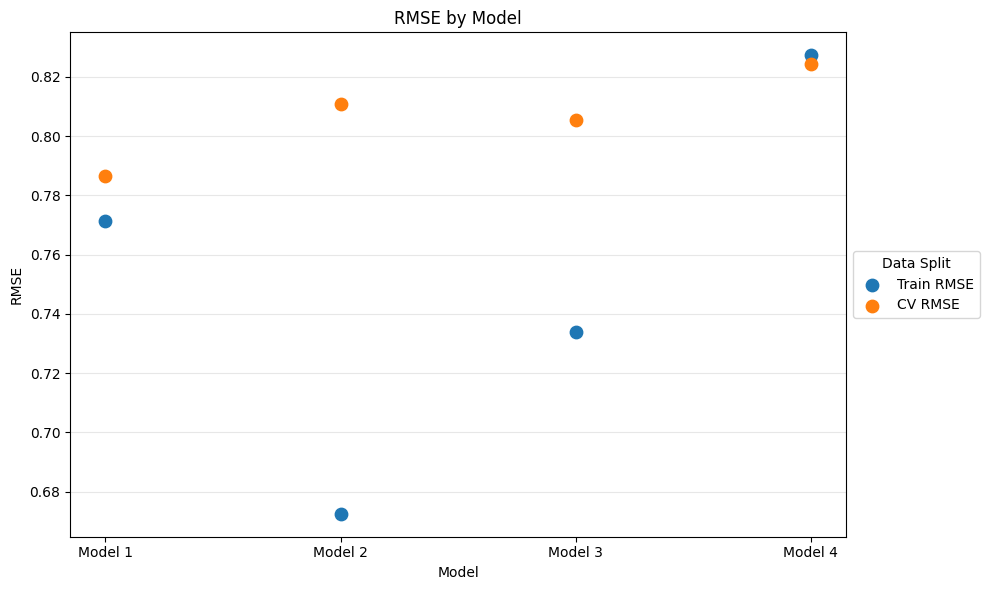

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(configs))
for split in ["Train RMSE", "CV RMSE"]:
    y_vals = [df[(df["Model"] == name) & (df["Split"] == split)]["RMSE"].values[0]
              for name, _, _ in configs]
    ax.scatter(x, y_vals, s=80, label=split)

ax.set_xticks(x)
ax.set_xticklabels([name for name, _, _ in configs])
ax.set_xlabel("Model")
ax.set_ylabel("RMSE")
ax.set_title("RMSE by Model")
ax.legend(title="Data Split", loc="center left", bbox_to_anchor=(1, 0.5))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

It looks like model 1 has the lowest RMSE, which means that it is the best model when using all dataset variables as predictor variables.